In [1]:
import itertools
import logging
import pathlib

import altair as alt
import geopandas as gpd
import numpy as np
import pandas as pd
import shapely
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.stats import norm

import pitchmark.osm

alt.renderers.enable('mimetype')
logger = logging.getLogger(__name__)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
METER_PER_FOOT = 0.305
METER_PER_YARD = 3 * METER_PER_FOOT
METER_PER_INCH = METER_PER_FOOT / 12
GRAVITY = 9.8 / METER_PER_YARD  # yd/s^2
MOI_SOLID_SPHERE = 0.4
BALL_RADIUS = 0.84 / 36  # yd
HOLE_RADIUS = 2.125 / 36  # yd

## Real green (Augusta National 16th)

In [3]:
map_path = pathlib.Path().cwd().parent / "data-raw" / "OpenStreetMap" / "augusta_national" / "map.osm"
handler = pitchmark.osm.GolfHandler()
handler.apply_file(map_path)
fc = handler.feature_collection
augusta_national = pitchmark.Course.from_featurecollection(fc)

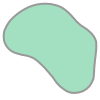

In [4]:
redbud = augusta_national.holes[15]
redbud_flag = augusta_national.transformer_to_local.transform(*redbud.path.coords[-1])
redbud_green = redbud.gdf[
    redbud.gdf.contains(shapely.Point(redbud_flag))
    & (redbud.gdf["course_area"] == "putting_green")
].unary_union
redbud_green_surround = redbud_green.buffer(5.0)
shapely.prepare(redbud_green_surround)
redbud_green_surround

In [5]:
redbud_mesh_file = pathlib.Path().cwd().parent / "data-raw" / "USGS_LIDAR" / "redbud_mesh.csv"
redbud_mesh_df = pd.read_csv(redbud_mesh_file, index_col=0)
redbud_mesh_df["geometry"] = gpd.GeoSeries.from_wkt(redbud_mesh_df["geometry"])
redbud_mesh_df

,geometry,x,y,z,normal_x,normal_y,normal_z,slope_heading,slope_grade
0,"POLYGON Z ((-722.370 -324.132 70.786, -723.880...",-723.129016,-326.857478,70.750255,-0.447005,0.136095,-0.884118,286.933337,46.726346
1,"POLYGON Z ((-722.370 -324.132 70.786, -723.137...",-722.590392,-325.580938,70.787177,0.012621,-0.001231,0.999920,95.571186,1.268077
2,"POLYGON Z ((-722.370 -324.132 70.786, -722.264...",-721.602992,-324.812896,70.755471,0.040295,0.000333,0.999188,89.527164,4.029670
3,"POLYGON Z ((-722.370 -324.132 70.786, -720.174...",-721.041210,-323.835504,70.746486,0.037559,-0.034685,0.998692,132.721782,5.112406
4,"POLYGON Z ((-722.370 -324.132 70.786, -720.579...",-721.589934,-323.186278,70.783272,0.029778,-0.021502,0.999325,125.832017,3.673009
...,...,...,...,...,...,...,...,...,...
22263,"POLYGON Z ((-595.573 -498.149 69.296, -595.955...",-596.007229,-497.790756,69.289246,-0.019387,-0.005579,0.999796,253.945912,2.017335
22264,"POLYGON Z ((-596.494 -497.967 69.279, -595.955...",-596.571854,-497.293754,69.286532,-0.010101,-0.012607,0.999870,218.701699,1.615465
22265,"POLYGON Z ((-597.267 -496.658 69.288, -596.974...",-597.360815,-495.569077,69.303853,0.000983,-0.014904,0.999888,176.224626,1.493644
22266,"POLYGON Z ((-596.513 -487.339 69.293, -594.856...",-595.458970,-487.231491,69.273740,0.016208,0.016165,0.999738,45.075177,2.289144


In [6]:
redbud_gdf = gpd.GeoDataFrame(redbud_mesh_df, crs=redbud.gdf.crs)
redbud_green_gdf = redbud_gdf[redbud_gdf.within(redbud_green)]
redbud_green_gdf

,geometry,x,y,z,normal_x,normal_y,normal_z,slope_heading,slope_grade
16475,"POLYGON Z ((-683.763 -324.048 71.312, -684.485...",-683.970501,-324.530043,71.281730,0.000468,-0.062113,0.998069,179.567941,6.211507
16476,"POLYGON Z ((-683.763 -324.048 71.312, -683.664...",-683.561854,-324.353691,71.290803,0.010795,-0.060915,0.998085,169.950361,6.186425
16477,"POLYGON Z ((-683.259 -324.116 71.302, -683.664...",-683.071955,-324.330614,71.289173,0.003234,-0.057009,0.998368,176.753405,5.710110
16478,"POLYGON Z ((-682.293 -323.979 71.307, -683.664...",-682.943513,-325.356133,71.244901,-0.007210,-0.041449,0.999115,189.867429,4.207106
16479,"POLYGON Z ((-682.293 -323.979 71.307, -682.874...",-682.254569,-326.200401,71.214483,-0.006383,-0.041598,0.999114,188.723407,4.208492
...,...,...,...,...,...,...,...,...,...
22023,"POLYGON Z ((-658.128 -351.548 70.023, -658.679...",-658.215134,-352.283345,69.994285,-0.035212,-0.034985,0.998767,225.184621,4.963706
22024,"POLYGON Z ((-676.125 -341.500 70.361, -677.146...",-676.698281,-341.760876,70.356190,-0.001592,-0.014204,0.999898,186.394403,1.429321
22025,"POLYGON Z ((-665.132 -352.771 69.978, -665.407...",-665.168112,-353.035570,69.972188,0.021161,-0.022998,0.999512,137.382322,3.125204
22026,"POLYGON Z ((-684.841 -339.392 70.550, -684.776...",-684.902956,-339.032578,70.534576,0.034734,0.049123,0.998189,35.263288,6.016235


In [7]:
surround_features = pitchmark.plotting.chart_course(redbud.gdf.clip(redbud_green_surround))

In [8]:
grades = (alt.Chart(redbud_green_gdf)
    .mark_geoshape(
        filled=True,
        color="lightgray",
    )
    .encode(
        color=alt.Color("slope_grade:Q", scale=alt.Scale(domain=[0, 12.0], scheme="greys"))
    )
    .project(
        type="identity",
        reflectY=True,
    )
)

In [ ]:
hover = alt.selection_single(
    name='hover',
    on='mouseover',
    nearest=True,
    empty='none'
)
zoom = alt.selection_interval(
    name='zoom',
    bind='scales'
)
inclines = (
    alt.Chart(redbud_green_gdf)
    .mark_point(
        shape="wedge",
        filled=True,
    )
    .encode(
        longitude="x",
        latitude="y",
        color=alt.condition(
            selector,
            alt.value("red"),
            alt.value("black")
        ),
        angle="slope_heading",
        size="slope_grade",
        tooltip=["x", "y", "z", "slope_heading", "slope_grade"],
    )
    .add_selection(hover, zoom)
    .project(
        type="identity",
        reflectY=True,
    )
    .properties(
        width=800,
        height=800,
    )
)


In [10]:
hole_location = (-681.0, -339.5)
hole_disk = gpd.GeoDataFrame(
    geometry=[shapely.buffer(shapely.Point(hole_location), HOLE_RADIUS)],
)
hole_disk_exaggerated = gpd.GeoDataFrame(
    geometry=[shapely.buffer(shapely.Point(hole_location), 5*HOLE_RADIUS)],
)
hole_plot = (
    alt.Chart(hole_disk)
    .mark_geoshape(color="black")
)
hole_plot_exaggerated = (
    alt.Chart(hole_disk_exaggerated)
    .mark_geoshape(color="black")
)
hole_plot

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html


In [ ]:
surround_features + grades + inclines + hole_plot_exaggerated

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html


In [12]:
def softness(stimp_reading, *, ball_moi = MOI_SOLID_SPHERE):
    init_ball_speed = 2  # yd/s
    return (init_ball_speed**2) * (1.0 + ball_moi) / (2 * GRAVITY * stimp_reading)

When repeatedly accessing a GeoDataFrame using the geometry, a STRtree is efficient.
This needs to be constructed manually so as to be reusable in many accessions.

In [13]:
class Green:
    def __init__(
        self,
        stimp,
        *,
        gdf=None,
        hole_location=None,
        hole_radius=HOLE_RADIUS,
        holing_vmax=1.63
    ):
        self.stimp = stimp
        self.softness = softness(stimp, ball_moi=MOI_SOLID_SPHERE)
        self.gdf = gdf
        if gdf is not None:
            self.strtree = shapely.STRtree(gdf.geometry)
        self.hole_location = (0.0, 0.0) if hole_location is None else hole_location
        self.hole_radius = hole_radius
        self.hole_radius_squared = hole_radius * hole_radius
        self.holing_vmax = holing_vmax
        

    def normal(self, x, y):
        if self.gdf is None:
            return [0.0, 0.1, np.sqrt(0.99)]
        point = shapely.Point(x, y)
        candidate_indices = self.strtree.query(point, predicate="within")
        try:
            gdf_index = candidate_indices[0]  # expects single hit
            row = self.gdf.iloc[gdf_index]
            return row[["normal_x", "normal_y", "normal_z"]].tolist()
        except IndexError:
            print(f"No candidate polygon found for {point=}\n")
    
    def squared_distance_to_hole(self, x, y):
        x0, y0 = self.hole_location
        return (x - x0) * (x - x0) + (y - y0) * (y - y0)
    
    def distance_to_hole(self, *args):
        return np.sqrt(self.squared_distance_to_hole(*args))

    def impact_function(self, u):
        x, y, vx, vy = u
        impact = self.squared_distance_to_hole(x, y) / self.hole_radius_squared
        v = np.sqrt(vx * vx + vy * vy)
        return v - self.holing_vmax * (1.0 - impact)
    


In [14]:
redbud_green_obj = Green(
    12.0,
    gdf=redbud_green_gdf,
    hole_location=hole_location,
)

In [15]:
redbud_green_obj.strtree.query(shapely.Point(-670.0, -340.0), predicate="within")[0]

1239

In [16]:
row = redbud_green_gdf.iloc[1239]
row[["x", "y", "z"]].tolist()

[-669.9962342447125, -339.5120771326153, 70.49109325555537]

x(t) = v(t) * t + x0
v(t) = a(t) * t + v0
a(t) = A

x0 = 0
v0 = 0
x(T) = X

gives X = A * T * T
so T = sqrt(X/A)

and v(T) = A * T = sqrt(A * X)

on a flat green, A = (g / I_b) * rho_g

In [17]:
redbud_green_obj.strtree.query(shapely.Point(-670.0, -340.0), predicate="within")[0]

1239

In [18]:
init_ball_position = (-672.0, -328.0)
hole_location = redbud_green_obj.hole_location
dx = hole_location[0] - init_ball_position[0]
dy = hole_location[1] - init_ball_position[1]
du = np.sqrt(dx*dx + dy*dy)
theta_init = np.arctan2(dy, dx)
v_init = np.sqrt(du * redbud_green_obj.softness * GRAVITY / MOI_SOLID_SPHERE)
print(v_init, theta_init)


2.9186408518574134 -2.234842489621581


In [19]:
redbud_green_obj.distance_to_hole(*init_ball_position)

14.603081866510234

In [20]:
print(dy, dx)

-11.5 -9.0


In [21]:
def simple_roll(t, u, green):
    x, y, vx, vy = u
    dx = vx
    dy = vy

    g = GRAVITY
    I_b = MOI_SOLID_SPHERE
    rho_g = green.softness

    nx, ny, nz = green.normal(x, y)
    grade = np.sqrt(1.0 - nz * nz)
    v = np.sqrt(vx * vx + vy * vy)

    dvx = (g / I_b) * (grade * nx - rho_g * vx / v)
    dvy = (g / I_b) * (grade * ny - rho_g * vy / v)
    return [dx, dy, dvx, dvy]

In [22]:
redbud_green_obj.normal(init_ball_position[0], init_ball_position[1])

[0.0003182651890103, -0.0196779173096313, 0.9998063203829152]

In [23]:
class MinBallSpeed:
    def __init__(self, min_speed, *, terminal=True, direction=0):
        self.terminal = terminal
        self.direction = direction
        self.min_speed = min_speed

    def __call__(self, t, u, green):
        x, y, vx, vy = u
        v2 = vx * vx + vy * vy
        return v2 - self.min_speed * self.min_speed

In [24]:
def holing_objective(sol, green):
    i_nearest = np.argmin([green.impact_function(u) for u in sol.y.T])
    try:
        t_min = sol.t[i_nearest - 1]
    except IndexError:
        t_min = sol.t[0]
    try:
        t_max = sol.t[i_nearest + 1]
    except IndexError:
        t_max = sol.t[-1]
    t_eval = np.arange(t_min, t_max + 0.01, 0.01)
    u_eval = sol.sol(t_eval).T
    impact = np.amin([green.impact_function(u) for u in u_eval])
    return impact

In [25]:
def simulate_rolls(vs, thetas, green, init, *, tspan=(0.0, 10.0), method="LSODA", min_ball_speed_tol=1e-3, **kwargs):
    x0, y0 = init
    end_points = list()
    sols = list()
    impacts = list()
    for v, theta in itertools.product(vs, thetas):
        vx0, vy0 = v * np.cos(theta), v * np.sin(theta)
        u0 = np.array([x0, y0, vx0, vy0])
        sol = solve_ivp(
            simple_roll,
            tspan,
            u0,
            method=method,
            dense_output=True,
            events=[MinBallSpeed(min_ball_speed_tol)],
            args=(green,),
            **kwargs,
        )
        end_point = np.hstack(([v, theta], sol.y.T[-1]))
        impact = holing_objective(sol, green)
        end_points.append(end_point)
        sols.append(sol)
        impacts.append(impact)

    return end_points, sols, impacts

In [26]:
end_points, sols, impacts = simulate_rolls([v_init], [theta_init], redbud_green_obj, init_ball_position)

In [27]:
sol = sols[0]

In [28]:
sol_df = pd.DataFrame(np.vstack(([sol.t], sol.y)).T, columns=["t", "x", "y", "vx", "vy"])
sol_df["v"] = np.sqrt(sol_df["vx"]**2 + sol_df["vy"]**2)
sol_df

,t,x,y,vx,vy,v
0,0.000000,-672.000000,-328.000000,-1.798782,-2.298444,2.918641
1,0.141508,-672.247376,-328.316053,-1.748116,-2.233483,2.836257
2,0.283016,-672.487578,-328.622917,-1.697446,-2.168525,2.753874
3,0.532219,-672.888781,-329.135376,-1.609943,-2.056390,2.611638
4,0.781423,-673.268640,-329.620041,-1.524243,-1.944899,2.471022
...,...,...,...,...,...,...
63,6.796374,-677.090705,-335.412780,-0.001064,-0.003119,0.003296
64,6.797914,-677.090707,-335.412784,-0.000873,-0.002563,0.002708
65,6.799454,-677.090708,-335.412788,-0.000683,-0.002007,0.002120
66,6.801546,-677.090709,-335.412791,-0.000425,-0.001251,0.001321


In [ ]:
sol_points = alt.Chart(sol_df).mark_point(clip=True).encode(
    longitude="x",
    latitude="y",
    color="v",
)
hole_plot + sol_points

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html


In [ ]:
surround_features + grades + inclines + hole_plot_exaggerated + sol_points

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html


In [31]:
broadie_putts_gained = pd.DataFrame(
    {
        "distance_ft": [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 40, 50, 60, 90],
        "avg_putts": [
            1.0,
            1.01,
            1.05,
            1.14,
            1.24,
            1.34,
            1.43,
            1.5,
            1.56,
            1.61,
            1.78,
            1.87,
            1.98,
            2.06,
            2.14,
            2.21,
            2.36,
        ],
    }
)
approx_putts = interp1d(
    broadie_putts_gained["distance_ft"] / 3,  # yd
    broadie_putts_gained["avg_putts"],
    fill_value="extrapolate"
)


In [32]:
def aim_objective_inner(x, green, init_position, *, v_cv=0.06, theta_sd=np.deg2rad(1.0)):
    v, theta = x
    logging.debug(f"Simulating rolls for bundle centered at {v=}, {theta=}...")
    vs = v * np.geomspace(1.0 - 2 * v_cv, 1.0 + 2 * v_cv, 9)
    thetas = theta + np.linspace(-2 * theta_sd, 2 * theta_sd, 9)
    # vs = v * norm(1, v_cv).ppf(np.linspace(0.025, 0.975, 11))
    # thetas = norm(theta, np.deg2rad(theta_sd)).ppf(np.linspace(0.025, 0.975, 11))
    return simulate_rolls(vs, thetas, green, init_position)


In [33]:
square_block_2sigma = itertools.product(np.linspace(-2.0, 2.0, 9), np.linspace(-2.0, 2.0, 9))

weights = [
    norm.pdf(x) * norm.pdf(y)
    for x, y in square_block_2sigma
]
weights /= sum(weights)


def approximate_scores(end_points, impacts, green, *, putting_approximant=approx_putts):
    return [
        putting_approximant(green.distance_to_hole(u[2], u[3])) if impact >= 0 else 0
        for u, impact in zip(end_points, impacts)
    ]

def aim_objective(x, green, init_position, **kwargs):
    try:
        end_points, _, impacts = aim_objective_inner(x, green, init_position, **kwargs)
    except:
        return np.Inf
    scores = approximate_scores(end_points, impacts, green)

    return sum(score * weight for score, weight in zip(scores, weights))

In [34]:
end_points, sols, impacts = aim_objective_inner((v_init, theta_init), redbud_green_obj, init_ball_position)

In [35]:
df = pd.DataFrame(end_points, columns=["v_init", "theta", "x", "y", "vx_end", "vy_end"])
df["impact"] = impacts
df["holed"] = df["impact"] < 0.0
df["score"] = approximate_scores(end_points, impacts, redbud_green_obj)

In [ ]:
end_points_cloud = (
    alt.Chart(df)
    .mark_point(filled=True)
    .encode(
        longitude="x",
        latitude="y",
        color=alt.condition(
            selector,
            alt.value("red"),
            "score:Q",
        ),
        shape="holed",
        tooltip=["v_init", "theta", "x", "y", "impact", "score:Q"],
    )
    # .project(
    #     type="identity",
    #     reflectY=True,
    # )
    .add_selection(selector)
    .properties(width=400, height=400)
)
hole_plot + end_points_cloud

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html


In [ ]:
surround_features + grades + hole_plot_exaggerated + end_points_cloud

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html


In [38]:
def take_trajectory(sol):
    df = pd.DataFrame(sol.y.T, columns=["x", "y", "vx", "vy"])
    df["t"] = sol.t
    return(df)

middle_trajectory = take_trajectory(sols[len(sols) // 2])
middle_trajectory_plot = (
    alt.Chart(middle_trajectory)
    .mark_line(color="black", strokeWidth=0.5)
    .encode(
        longitude="x",
        latitude="y",
        detail="sol_index:N"
    )
    .properties(width=600, height=400)
)
middle_trajectory_plot

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html


In [ ]:
surround_features + grades + hole_plot_exaggerated + end_points_cloud + middle_trajectory_plot

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html


In [40]:
logger.setLevel(logging.DEBUG)
optim_result = minimize(
    aim_objective,
    (v_init, theta_init),
    args=(redbud_green_obj, init_ball_position),
    method="Nelder-Mead",
    bounds=[(0.0, 20.0), (-np.pi, np.pi)],
    options={"maxiter": 10, "disp": True},
)
optim_result

No candidate polygon found for point=<POINT (-679.207 -342.015)>

No candidate polygon found for point=<POINT (-682.381 -341.047)>

No candidate polygon found for point=<POINT (-680.706 -341.069)>

No candidate polygon found for point=<POINT (-682.27 -339.77)>

No candidate polygon found for point=<POINT (-681.969 -340.061)>

No candidate polygon found for point=<POINT (-681.796 -340.288)>



C:\Users\istvan\AppData\Local\Temp\ipykernel_12032\3004664189.py:2: RuntimeWarning: Maximum number of iterations has been exceeded.
  optim_result = minimize(


       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 1.378579792996921
             x: [ 3.477e+00 -2.253e+00]
           nit: 10
          nfev: 20
 final_simplex: (array([[ 3.477e+00, -2.253e+00],
                       [ 3.502e+00, -2.207e+00],
                       [ 3.452e+00, -2.217e+00]]), array([ 1.379e+00,  1.391e+00,  1.434e+00]))

In [41]:
end_points, sols, impacts = aim_objective_inner(optim_result.x, redbud_green_obj, init_ball_position)

In [42]:
df = pd.DataFrame(end_points, columns=["v_init", "theta", "x", "y", "vx_end", "vy_end"])
df["impact"] = impacts
df["holed"] = df["impact"] < 0.0
df["score"] = approximate_scores(end_points, impacts, redbud_green_obj)

In [43]:
end_points_cloud = (
    alt.Chart(df)
    .mark_point(filled=True)
    .encode(
        longitude="x",
        latitude="y",
        color=alt.condition(
            selector,
            alt.value("red"),
            "score:Q",
        ),
        shape="holed",
        tooltip=["v_init", "theta", "x", "y", "impact", "score:Q"],
    )
    # .project(
    #     type="identity",
    #     reflectY=True,
    # )
    .add_selection(selector)
    .properties(width=400, height=400)
)
hole_plot + end_points_cloud

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html


In [44]:
middle_trajectory = take_trajectory(sols[len(sols) // 2])
middle_trajectory_plot = (
    alt.Chart(middle_trajectory)
    .mark_line(color="black", strokeWidth=0.5)
    .encode(
        longitude="x",
        latitude="y",
        detail="sol_index:N"
    )
)

In [45]:
surround_features + grades + hole_plot_exaggerated + end_points_cloud + middle_trajectory_plot

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html
